<a href="https://colab.research.google.com/github/Eng3mr5aled/Machine-Learning-_python/blob/main/task_in_W4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Setup:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
df = pd.read_csv('students.csv')
print('Shape:', df.shape)
df.head(20)

Shape: (200, 7)


,study_hours,sleep_hours,attendance_pct,prev_score,final_score,grade,passed
0,1.7,7.8,84,41,63.2,C,1
1,8.0,4.3,96,74,90.1,A,1
2,4.9,7.7,55,57,66.3,C,1
3,7.5,8.7,93,45,85.8,A,1
4,9.8,7.0,76,87,99.4,A,1
5,5.8,5.4,84,78,79.6,B,1
6,5.5,7.4,53,71,77.6,B,1
7,1.6,7.6,72,90,67.1,C,1
8,3.4,7.3,92,54,71.2,B,1
9,5.5,4.7,95,94,85.5,A,1


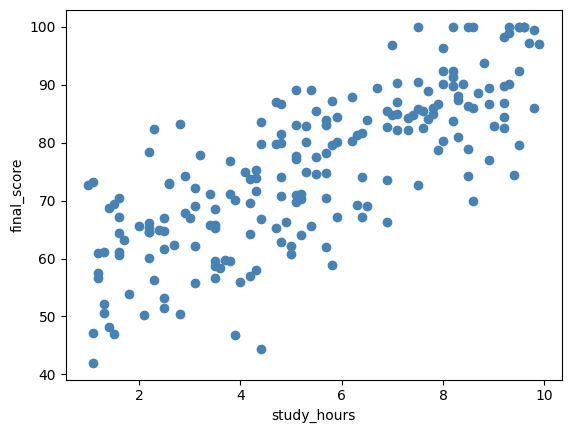

In [ ]:
# Quick look at both features vs Salary
plt.scatter(df['study_hours'], df['final_score'], color='steelblue')
plt.xlabel('study_hours')
plt.ylabel('final_score')
plt.show()

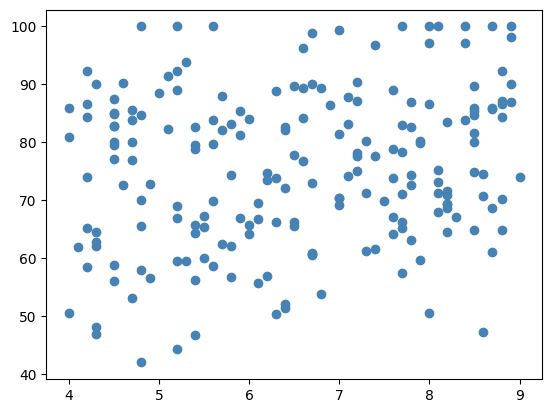

In [ ]:
# Quick look at both features vs Salary
plt.scatter(df['sleep_hours'], df['final_score'], color='steelblue')


plt.show()

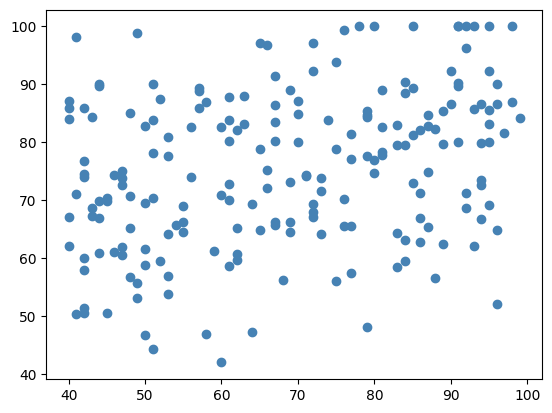

In [ ]:
# Quick look at both features vs Salary
plt.scatter(df['attendance_pct'], df['final_score'], color='steelblue')


plt.show()

## Linear Regrassion  :

In [ ]:
from sklearn.model_selection import train_test_split
X = df[['study_hours', 'sleep_hours', 'attendance_pct', 'prev_score']]
y = df['final_score']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f'Train: {len(X_train)} rows  |  Test: {len(X_test)} rows')

Train: 160 rows  |  Test: 40 rows


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"R²:   {r2:.3f}")

print("\nIntercept:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:<16} {coef:.4f}")

RMSE: 4.845
MAE:  3.757
R²:   0.889

Intercept: 4.554030795680319
  study_hours      4.0399
  sleep_hours      1.9381
  attendance_pct   0.1831
  prev_score       0.3524


In [ ]:
def predict_score(study_hours, sleep_hours, attendance_pct, prev_score):
    new_student = pd.DataFrame([{
        'study_hours': study_hours,
        'sleep_hours': sleep_hours,
        'attendance_pct': attendance_pct,
        'prev_score': prev_score
    }])
    predicted = model.predict(new_student)[0]
    return round(predicted, 2)


score = predict_score(study_hours=6.5, sleep_hours=7, attendance_pct=85, prev_score=70)
print(f"Predicted final_score: {score}")

Predicted final_score: 84.61


Accuracy: 0.600

Classification Report:
              precision    recall  f1-score   support

           A       0.73      0.80      0.76        10
           B       0.56      0.60      0.58        15
           C       0.55      0.50      0.52        12
        Fail       0.50      0.33      0.40         3

    accuracy                           0.60        40
   macro avg       0.58      0.56      0.57        40
weighted avg       0.59      0.60      0.59        40

Confusion Matrix (rows=actual, cols=predicted):
      A  B  C  Fail
A     8  2  0     0
B     3  9  3     0
C     0  5  6     1
Fail  0  0  2     1

--- Tree structure ---
|--- study_hours <= 6.60
|   |--- study_hours <= 3.75
|   |   |--- prev_score <= 77.00
|   |   |   |--- sleep_hours <= 4.85
|   |   |   |   |--- class: Fail
|   |   |   |--- sleep_hours >  4.85
|   |   |   |   |--- class: C
|   |   |--- prev_score >  77.00
|   |   |   |--- attendance_pct <= 52.50
|   |   |   |   |--- class: C
|   |   |   |--- attendan

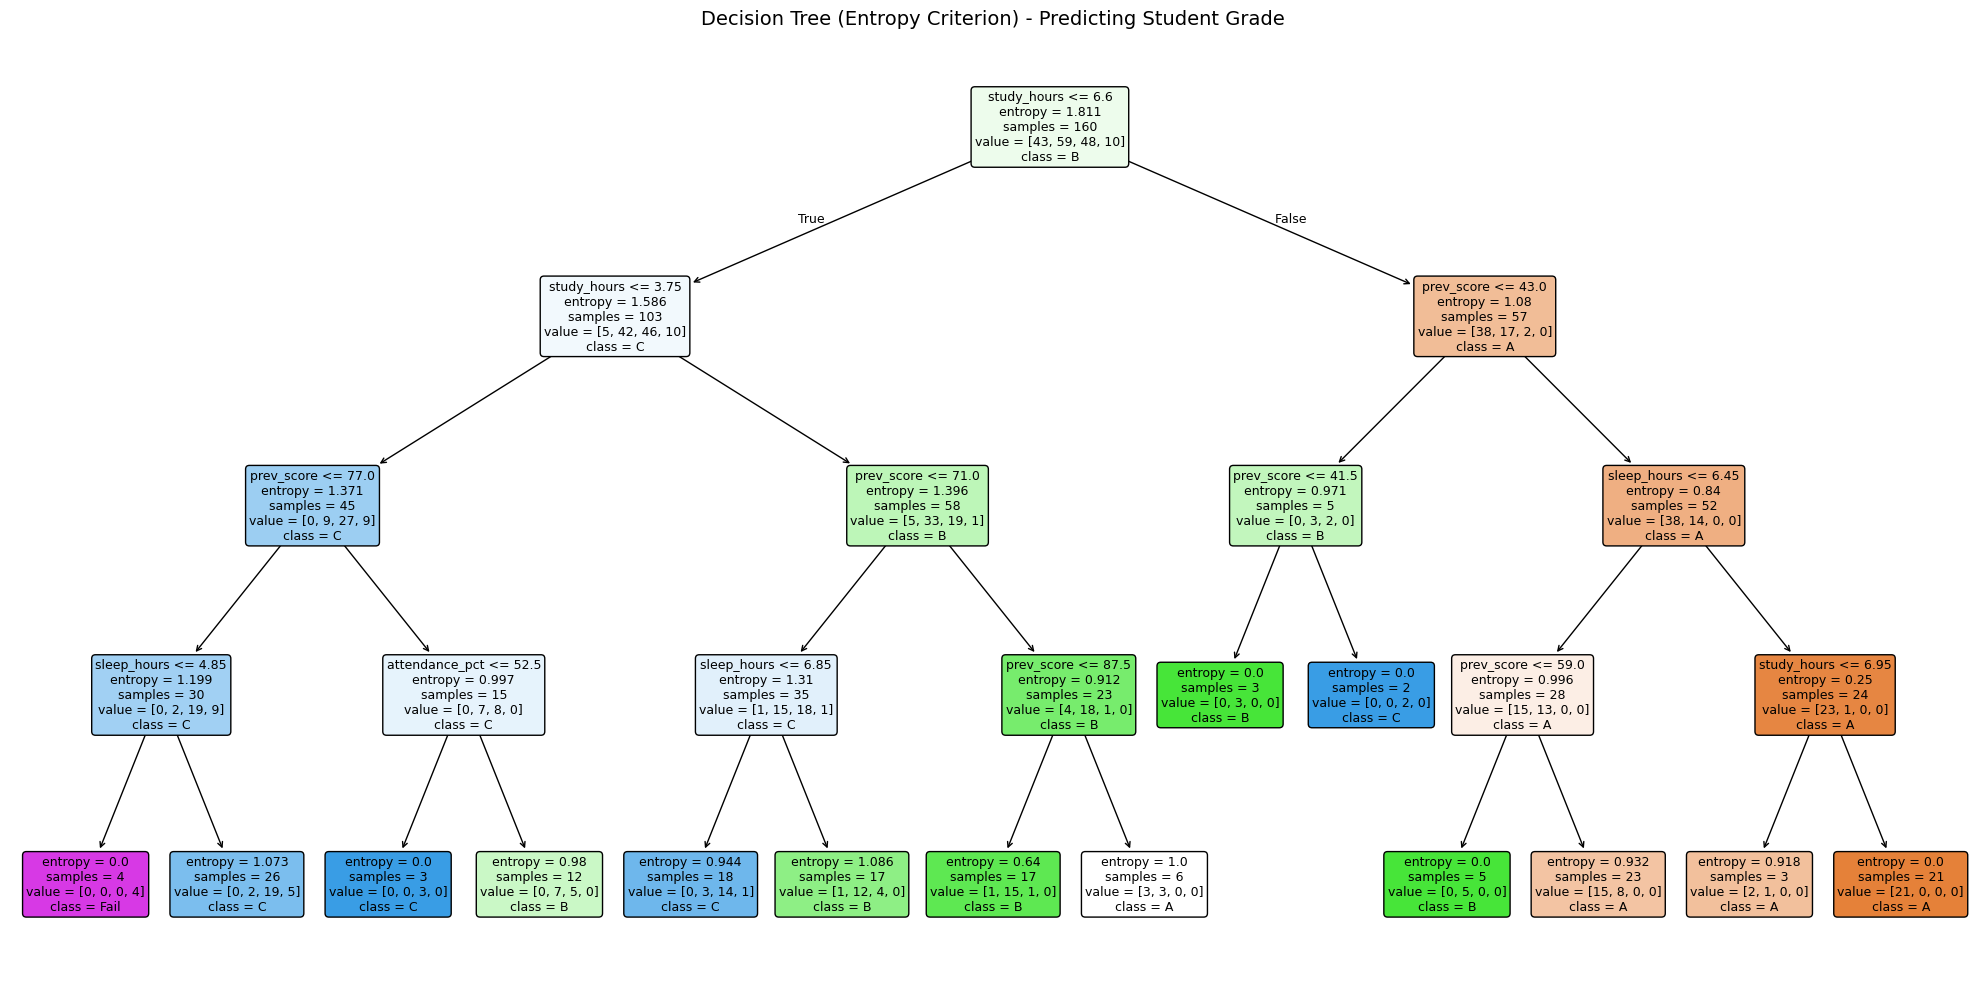

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ============================================================
# 1. تحميل البيانات
# ============================================================
df = pd.read_csv('students.csv')

X = df[['study_hours', 'sleep_hours', 'attendance_pct', 'prev_score']]
y = df['grade']   # multi-class target: A / B / C / Fail

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2. بناء Decision Tree باستخدام Entropy (Cross-Entropy criterion)
# ============================================================
tree = DecisionTreeClassifier(
    criterion='entropy',   # ده اللي بيستخدم Information Gain المبني على Entropy
    max_depth=4,
    random_state=42
)
tree.fit(X_train, y_train)

# ============================================================
# 3. التقييم
# ============================================================
y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix (rows=actual, cols=predicted):")
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(pd.DataFrame(cm, index=labels, columns=labels))

# ============================================================
# 4. عرض شجرة القرار كـ نص (يوضح كل split)
# ============================================================
print("\n--- Tree structure ---")
print(export_text(tree, feature_names=list(X.columns)))

# ============================================================
# 5. Feature Importance
# ============================================================
print("Feature Importance:")
for feat, imp in sorted(zip(X.columns, tree.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feat:<16} {imp:.4f}")

# ============================================================
# 6. حساب الـ Entropy الابتدائي يدويًا (زي ما الدكتور بيشرح)
# ============================================================
def entropy(y_series):
    probs = y_series.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

root_entropy = entropy(y_train)
print(f"\nRoot node entropy: {root_entropy:.4f} bits")

# ============================================================
# 7. رسم الشجرة
# ============================================================
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree (Entropy Criterion) - Predicting Student Grade", fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')